In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


2026-05-17 16:04:21.199880: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 16:04:21.210389: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779008661.223027   90018 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779008661.227195   90018 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779008661.237186   90018 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


In [3]:

BASE_PATHHASIL = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize256lv3/norm/dwt/"

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_tow_ids():

    inputs = layers.Input(shape=(32, 32, 3))

    # ===== Block A =====
    x = layers.SeparableConv2D(32, (3,3), padding="same")(inputs)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    # ===== Block B (Residual) =====
    shortcut = layers.Conv2D(64, (1,1), padding="same")(x)

    x = layers.SeparableConv2D(64, (3,3), padding="same")(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    # ===== Block C =====
    x = layers.SeparableConv2D(128, (3,3), padding="same")(x)
    x = layers.ReLU()(x)
    x = layers.BatchNormalization()(x)

    x = layers.GlobalAveragePooling2D()(x)

    # ===== Dense Head =====
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [5]:

train_data = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_train_dwt.npz"))
test_data  = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_test_dwt.npz"))
val_data   = np.load(os.path.join(BASE_PATHHASIL, "tow_ids_eval_dwt.npz"))

X_train = train_data["X"]
y_train = train_data["y"]

X_test  = test_data["X"]
y_test  = test_data["y"]

X_val   = val_data["X"]
y_val   = val_data["y"]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)
print(X_val.shape, y_val.shape)

(3291, 32, 32, 3) (3291,)
(3092, 32, 32, 3) (3092,)
(1410, 32, 32, 3) (1410,)


In [6]:
tf.keras.backend.clear_session()

model = build_cnn_tow_ids()
model.summary()


I0000 00:00:1779008662.646547   90018 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1173 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 32, 32,    │        155 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ separable_conv2d… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ re_lu[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 16, 16,    │      2,400 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 16, 16,    │          0 │ separable_conv2d… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        256 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 16, 16,    │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 16, 16,    │      8,896 │ re_lu_2[0][0]     │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 16, 16,    │          0 │ separable_conv2d… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │     66,048 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 228,348 (891.98 KB)

 Trainable params: 227,900 (890.23 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:


history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1,
    
)


Epoch 1/100


I0000 00:00:1779008664.841129   90148 service.cc:152] XLA service 0x7795c4017630 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779008664.841146   90148 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-05-17 16:04:24.888572: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779008665.245944   90148 cuda_dnn.cc:529] Loaded cuDNN version 91701
2026-05-17 16:04:26.924044: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332_0', 44 bytes spill stores, 44 bytes spill loads

2026-05-17 16:04:27.091508: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fus

 89/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9073 - loss: 0.2668

2026-05-17 16:04:34.867252: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332', 488 bytes spill stores, 488 bytes spill loads

2026-05-17 16:04:34.975570: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1332_0', 36 bytes spill stores, 36 bytes spill loads

2026-05-17 16:04:36.303435: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2183', 28 bytes spill stores, 32 bytes spill loads

2026-05-17 16:04:37.051217: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2187', 32 bytes spill stores, 32 bytes spill loads

2026-05-17 16:04:37.192289: I extern

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9129 - loss: 0.2524

2026-05-17 16:04:44.283233: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 64 bytes spill stores, 64 bytes spill loads



103/103 ━━━━━━━━━━━━━━━━━━━━ 23s 127ms/step - accuracy: 0.9511 - loss: 0.1548 - val_accuracy: 0.7291 - val_loss: 0.5966
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9775 - loss: 0.0860 - val_accuracy: 0.7390 - val_loss: 0.4640
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9830 - loss: 0.0605 - val_accuracy: 0.9702 - val_loss: 0.2845
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9830 - loss: 0.0574 - val_accuracy: 0.9681 - val_loss: 0.1240
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9885 - loss: 0.0405 - val_accuracy: 0.9794 - val_loss: 0.0634
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9863 - loss: 0.0485 - val_accuracy: 0.9241 - val_loss: 0.2688
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9903 - loss: 0.0364 - val_accuracy: 0.9702 - val_loss: 0.1167
Epoch 8/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.8

Threshold 0.5

In [8]:
# === TEST ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)

print("\n=== TEST RESULT ===")
print("Loss :", test_loss)
print("Acc  :", test_acc)

86/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9537 - loss: 1.6558

2026-05-17 16:05:30.119505: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151_0', 36 bytes spill stores, 36 bytes spill loads

2026-05-17 16:05:31.396033: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_151', 488 bytes spill stores, 488 bytes spill loads



97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9615 - loss: 0.4976

=== TEST RESULT ===
Loss : 0.4976193904876709
Acc  : 0.9615135788917542


In [9]:
y_prob = model.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int)


97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step


Confusion Matrix + Nilai Dasar

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)


TP: 1434
FP: 61
TN: 1539
FN: 58


Hitung Semua Metric Sesuai Persamaan Paper

In [11]:
accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn)
precision = tp / (tp + fp)
fmeasure  = 2 * precision * recall / (precision + recall)

print("\n=== Metrics (Threshold 0.5) ===")
print(f"Accuracy : {accuracy:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"Precision: {precision:.6f}")
print(f"F-measure: {fmeasure:.6f}")



=== Metrics (Threshold 0.5) ===
Accuracy : 0.961514
Recall   : 0.961126
Precision: 0.959197
F-measure: 0.960161


In [12]:
# === Confusion values sudah ada ===
# tp, tn, fp, fn

accuracy  = (tp + tn) / (tp + tn + fp + fn)
recall    = tp / (tp + fn + 1e-12)
precision = tp / (tp + fp + 1e-12)
f1        = 2 * precision * recall / (precision + recall + 1e-12)

# tambahan
fpr = fp / (fp + tn + 1e-12)
fnr = fn / (fn + tp + 1e-12)

print("\n=== Metrics (Threshold 0.5) ===")
print(f"Accuracy  : {accuracy:.6f}")
print(f"Precision : {precision:.6f}")
print(f"Recall    : {recall:.6f}")
print(f"F1        : {f1:.6f}")
print(f"FPR       : {fpr:.6f}")
print(f"FNR       : {fnr:.6f}")
print(f"FP        : {fp}")
print(f"FN        : {fn}")


=== Metrics (Threshold 0.5) ===
Accuracy  : 0.961514
Precision : 0.959197
Recall    : 0.961126
F1        : 0.960161
FPR       : 0.038125
FNR       : 0.038874
FP        : 61
FN        : 58


ROC Curve + AUC (Persamaan 13)

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.6f}")


AUC: 0.989091


Plot ROC

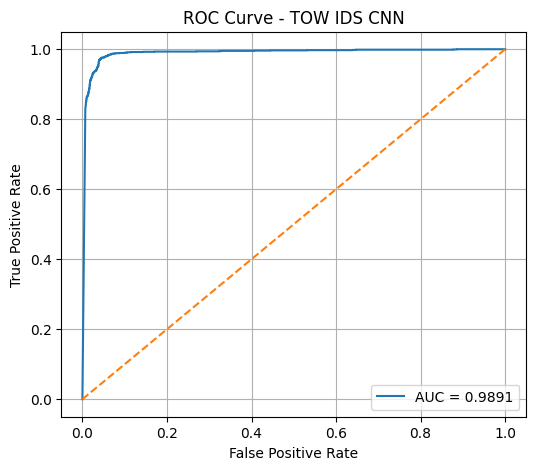

In [14]:
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - TOW IDS CNN")
plt.legend()
plt.grid()
plt.show()


Plot Confusion Matrix

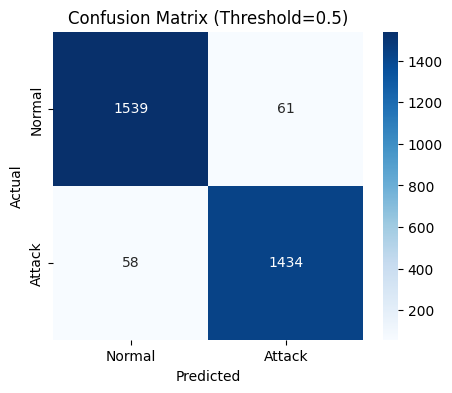

In [15]:
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.xlabel("Predicted")                                                                                         
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold=0.5)")
plt.show()


Plot Confusion Matrix

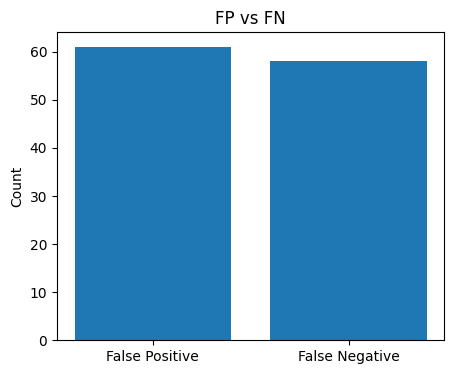

In [16]:
plt.figure(figsize=(5,4))
plt.bar(["False Positive", "False Negative"], [fp, fn])
plt.title("FP vs FN")
plt.ylabel("Count")
plt.show()


Plot FP vs FN

In [17]:
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix
)

# =========================================
# PREDICT PROBABILITY
# =========================================

y_prob = model.predict(X_test).ravel()
y_true = y_test

# =========================================
# ROC CURVE
# =========================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

# =========================================
# YOU DEN INDEX
# =========================================

youden_index = tpr - fpr

best_idx = np.argmax(youden_index)

best_threshold = thresholds[best_idx]

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [18]:

print("========================================")
print("BEST THRESHOLD SEARCH")
print("========================================")
print(f"Best Threshold (Youden Index): {best_threshold:.6f}")

# =========================================
# PREDICTION WITH BEST THRESHOLD
# =========================================

y_pred_opt = (y_prob >= best_threshold).astype(int)

# =========================================
# CONFUSION MATRIX
# =========================================

cm_opt = confusion_matrix(y_true, y_pred_opt)

TN, FP, FN, TP = cm_opt.ravel()


BEST THRESHOLD SEARCH
Best Threshold (Youden Index): 0.185081


In [19]:

# =========================================
# METRICS
# =========================================

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP + 1e-12)

recall = TP / (TP + FN + 1e-12)

f1 = 2 * precision * recall / (precision + recall + 1e-12)

FPR = FP / (FP + TN + 1e-12)

FNR = FN / (FN + TP + 1e-12)

# specificity opsional
specificity = TN / (TN + FP + 1e-12)

# =========================================
# PRINT METRICS
# =========================================

print("\n========================================")
print("EVALUATION METRICS")
print("========================================")

print(f"Accuracy   : {accuracy:.6f}")
print(f"Precision  : {precision:.6f}")
print(f"Recall     : {recall:.6f}")
print(f"F1-score   : {f1:.6f}")

print("\n========================================")
print("IDS SPECIFIC METRICS")
print("========================================")

print(f"FPR        : {FPR:.6f}")
print(f"FNR        : {FNR:.6f}")
print(f"Specificity: {specificity:.6f}")


EVALUATION METRICS
Accuracy   : 0.965071
Precision  : 0.952880
Recall     : 0.975871
F1-score   : 0.964238

IDS SPECIFIC METRICS
FPR        : 0.045000
FNR        : 0.024129
Specificity: 0.955000


In [20]:

# =========================================
# ROC-AUC
# =========================================

print("\n========================================")
print("ROC-AUC")
print("========================================")

print(f"AUC Score  : {roc_auc:.6f}")


ROC-AUC
AUC Score  : 0.989091


In [21]:

# =========================================
# INFERENCE LATENCY
# =========================================

start = time.time()

_ = model.predict(X_test[:256], verbose=0)

latency = (time.time() - start) / 256

print("\n========================================")
print("INFERENCE PERFORMANCE")
print("========================================")

print(f"Inference time per sample: {latency:.6f} sec")


INFERENCE PERFORMANCE
Inference time per sample: 0.000300 sec


Threshold Optimization (Youden Index)

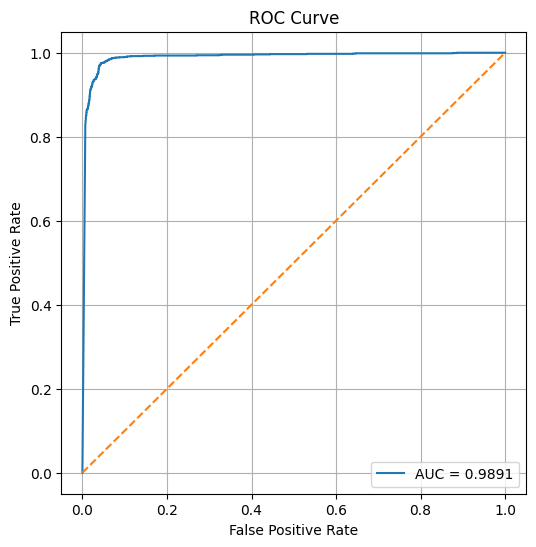

In [22]:

# =========================================
# ROC CURVE PLOT
# =========================================

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()